# IEEE-CIS Fraud Detection — Preprocessing & Feature Engineering


Before we can train any model, the data needs some cleaning up. There are 
columns with tons of missing values, text columns that need to be converted 
to numbers, and a few new features I want to try building from scratch.

## Table of Contents
1. [Setup & Load Data](#1-setup--load-data)
2. [Drop High-Missing Columns](#2-drop-high-missing-columns)
3. [Fill Remaining Missing Values](#3-fill-remaining-missing-values)
4. [Encode Categorical Features](#4-encode-categorical-features)
5. [Feature Engineering](#5-feature-engineering)
6. [Save Processed Data](#6-save-processed-data)save-processed-data)

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

os.makedirs('charts', exist_ok=True)
print("Ready.")

Ready.


In [33]:
data_path = "./../data"

train_transaction = pd.read_csv(os.path.join(data_path, 'train_transaction.csv'))
train_identity    = pd.read_csv(os.path.join(data_path, 'train_identity.csv'))

df = train_transaction.merge(train_identity, on='TransactionID', how='left')

print(f"Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

Loaded: 590,540 rows, 434 columns


In [34]:
temp_data_to_check = df[:100].copy()
temp_data_to_check

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2987095,0,88120,59.0,W,2538,476.0,150.0,visa,166.0,debit,330.0,87.0,NaN,NaN,anonymous.com,NaN,1.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,1.0,72.0,72.0,71.0,71.0,71.0,NaN,NaN,NaN,NaN,71.0,NaN,NaN,NaN,NaN,71.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,2987096,0,88131,108.5,W,15121,555.0,150.0,visa,226.0,debit,420.0,87.0,NaN,NaN,gmail.com,NaN,202.0,208.0,0.0,0.0,128.0,181.0,0.0,0.0,64.0,0.0,182.0,0.0,258.0,108.0,0.0,NaN,NaN,211.0,0.0,NaN,NaN,NaN,NaN,200.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

## 2. Drop High-Missing Columns

In the EDA I noticed a lot of the `id_*` columns were 99% empty. I looked it 
up and apparently this is because the identity file only covers some of the 
transactions — not all of them have identity records attached.

Keeping columns that are almost entirely empty doesn't seem useful, so I'm 
dropping anything that's more than 90% missing.

In [35]:
# Calculate missing rate per column
missing_rate = df.isnull().mean()

# Keep columns with less than 90% missing
cols_to_keep = missing_rate[missing_rate < 0.90].index.tolist()
cols_dropped = df.shape[1] - len(cols_to_keep)

df = df[cols_to_keep]

print(f"Columns before: {df.shape[1] + cols_dropped}")
print(f"Columns dropped (>90% missing): {cols_dropped}")
print(f"Columns remaining: {df.shape[1]}")

Columns before: 434
Columns dropped (>90% missing): 12
Columns remaining: 422


## 3. Fill Remaining Missing Values

Still have some missing values left after the drop. I need to fill these 
because the model can't handle NaNs.

For number columns I'm using -999. I read that this is better than filling 
with the mean because XGBoost can actually learn that -999 means "this data 
wasn't there" — which might itself be a useful signal. For text columns I'm 
just using 'Unknown'.reason.

In [36]:
# Separate column types
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove target from numeric list
num_cols = [c for c in num_cols if c != 'isFraud']

# Fill
df[num_cols] = df[num_cols].fillna(-999)
df[cat_cols] = df[cat_cols].fillna('Unknown')

print(f"Numeric columns filled with -999:      {len(num_cols)}")
print(f"Categorical columns filled with Unknown: {len(cat_cols)}")
print(f"Remaining missing values: {df.isnull().sum().sum()}")

Numeric columns filled with -999:      392
Categorical columns filled with Unknown: 29
Remaining missing values: 0


## 4. Encode Categorical Features

The model only works with numbers, so any text columns need to be converted. 
Label encoding just assigns each unique value an integer — so "visa" might 
become 0, "mastercard" becomes 1, etc.

In [43]:
#from sklearn.preprocessing import LabelEncoder

#le = LabelEncoder()
#label_encoders = {}  # store encoders in case we need them later

#for col in cat_cols:
#    df[col] = le.fit_transform(df[col].astype(str))
#    label_encoders[col] = le

cat_mappings = {}

for col in cat_cols:
    # get sorted unique values
    uniques = sorted(df[col].astype(str).unique())

    # build mapping: category → integer
    mapping = {cat: i for i, cat in enumerate(uniques)}

    # store mapping
    cat_mappings[col] = mapping

    # apply mapping
    df[col] = df[col].map(mapping)


print(f"Label encoded {len(cat_cols)} categorical columns:")
print(cat_cols)

Label encoded 29 categorical columns:
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


## 5. Feature Engineering

This is the part where you create new columns from the existing ones. I've 
seen this mentioned a lot in fraud detection articles as one of the most 
important steps — sometimes a derived feature tells the model more than 
the raw column it came from.

I'm adding:
- `hour` — what time of day the transaction happened. From the EDA we could 
  see fraud is higher at certain hours so this felt worth adding.
- `day_of_week` — similar idea, maybe fraud patterns differ by day.
- `log_amount` — the transaction amounts are all over the place. Taking the 
  log makes the distribution less extreme and easier for the model to work with.
- `amount_is_round` — I noticed some fraud transactions land on suspiciously 
  round numbers like $100 or $500 exactly. This flag captures that.
- `card1_fraud_rate` — for each card group, what fraction of its past 
  transactions were fraud. The idea is that some cards are just riskier.than others.

In [48]:
# Time-based features
df['hour']        = (df['TransactionDT'] / 3600).astype(int) % 24
df['day_of_week'] = (df['TransactionDT'] / 86400).astype(int) % 7

# Amount features
df['log_amount']     = np.log1p(df['TransactionAmt'])
df['amount_is_round'] = (df['TransactionAmt'] % 1 == 0).astype(int)

# Card-level fraud rate (target encoding with smoothing)
# This tells the model: "historically, how often does this card group commit fraud?"
card_fraud_rate = df.groupby('card1')['isFraud'].transform('mean')
df['card1_fraud_rate'] = card_fraud_rate

print("New features created:")
new_features = ['hour', 'day_of_week', 'log_amount', 'amount_is_round', 'card1_fraud_rate']
for f in new_features:
    print(f"  {f:25s} — sample values: {df[f].head(3).tolist()}")

New features created:
  hour                      — sample values: [0, 0, 0]
  day_of_week               — sample values: [1, 1, 1]
  log_amount                — sample values: [4.241326752570746, 3.4011973816621555, 4.0943445622221]
  amount_is_round           — sample values: [0, 1, 1]
  card1_fraud_rate          — sample values: [0.23255813953488372, 0.04685212298682284, 0.008122743682310469]


In [68]:
card1_rate_map = (
    df.groupby('card1')['isFraud']
      .mean()
      .to_dict()
)

print(len(df.card1.unique()))
len(df.card1_fraud_rate.unique())


13553


740

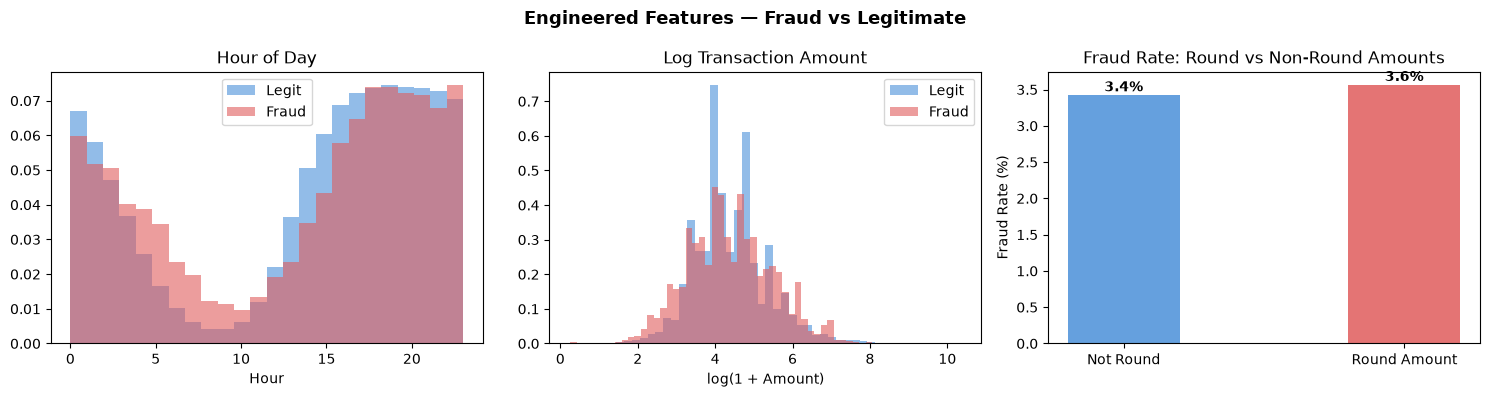

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Hour distribution
axes[0].hist(df[df['isFraud']==0]['hour'], bins=24, alpha=0.6, color='#4a90d9', label='Legit', density=True)
axes[0].hist(df[df['isFraud']==1]['hour'], bins=24, alpha=0.6, color='#e05c5c', label='Fraud', density=True)
axes[0].set_title('Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].legend()

# Log amount distribution
axes[1].hist(df[df['isFraud']==0]['log_amount'], bins=50, alpha=0.6, color='#4a90d9', label='Legit', density=True)
axes[1].hist(df[df['isFraud']==1]['log_amount'], bins=50, alpha=0.6, color='#e05c5c', label='Fraud', density=True)
axes[1].set_title('Log Transaction Amount')
axes[1].set_xlabel('log(1 + Amount)')
axes[1].legend()

# Round amount flag
round_fraud = df.groupby('amount_is_round')['isFraud'].mean() * 100
axes[2].bar(['Not Round', 'Round Amount'], round_fraud.values, color=['#4a90d9', '#e05c5c'], alpha=0.85, width=0.4)
axes[2].set_title('Fraud Rate: Round vs Non-Round Amounts')
axes[2].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(round_fraud.values):
    axes[2].text(i, v + 0.05, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Engineered Features — Fraud vs Legitimate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/07_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Save Processed Data

Saving the cleaned data here so I don't have to rerun all of this every 
time I open notebook 03.

In [50]:
# Separate features and target
TARGET = 'isFraud'
DROP_COLS = ['TransactionID', 'TransactionDT']  # not useful as model features

feature_cols = [c for c in df.columns if c not in [TARGET] + DROP_COLS]

X = df[feature_cols]
y = df[TARGET]

# Save
PROCESSED_DIR = os.path.join(data_path, 'processed')
os.makedirs(PROCESSED_DIR, exist_ok=True)

X.to_csv(os.path.join(PROCESSED_DIR, 'X_train.csv'), index=False)
y.to_csv(os.path.join(PROCESSED_DIR, 'y_train.csv'), index=False)

print(f"Saved X_train: {X.shape}")
print(f"Saved y_train: {y.shape}")
print(f"Location: {PROCESSED_DIR}")
print(f"\nFeature count: {X.shape[1]}")
print(f"Fraud labels:  {y.sum():,} ({y.mean()*100:.2f}%)")

Saved X_train: (590540, 424)
Saved y_train: (590540,)
Location: ./../data/processed

Feature count: 424
Fraud labels:  20,663 (3.50%)


In [51]:
feature_cols

['TransactionAmt',
 'ProductCD',
 'card1',
 'card2',
 'card3',
 'card4',
 'card5',
 'card6',
 'addr1',
 'addr2',
 'dist1',
 'P_emaildomain',
 'R_emaildomain',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9',
 'C10',
 'C11',
 'C12',
 'C13',
 'C14',
 'D1',
 'D2',
 'D3',
 'D4',
 'D5',
 'D6',
 'D8',
 'D9',
 'D10',
 'D11',
 'D12',
 'D13',
 'D14',
 'D15',
 'M1',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'V29',
 'V30',
 'V31',
 'V32',
 'V33',
 'V34',
 'V35',
 'V36',
 'V37',
 'V38',
 'V39',
 'V40',
 'V41',
 'V42',
 'V43',
 'V44',
 'V45',
 'V46',
 'V47',
 'V48',
 'V49',
 'V50',
 'V51',
 'V52',
 'V53',
 'V54',
 'V55',
 'V56',
 'V57',
 'V58',
 'V59',
 'V60',
 'V61',
 'V62',
 'V63',
 'V64',
 'V65',
 'V66',
 'V67',
 'V68',
 'V69',
 'V70',
 'V71',
 'V72',
 'V7

In [ ]:
def preprocessing_imcome_trans(meta_data, feature_cols, cat_mappings):
""""
meta_data: is a dataframe containing the raw value of only 1 incomming variable
feature_cols: those are feature needed for model input
"""
    cat_cols = meta_data.select_dtypes(include='object').columns.tolist()
    num_cols = meta_data.select_dtypes(include=[np.number]).columns.tolist()
    df[num_cols] = meta_data[num_cols].fillna(-999)
    df[cat_cols] = meta_data[cat_cols].fillna('Unknown')

    # mapping features
    for feature in cat_mappings.keys():
         meta_data[feature] = meta_data[feature].map(cat_mappings[feature])
        # Time-based features
    meta_data['hour']        = (meta_data['TransactionDT'] / 3600).astype(int) % 24
    meta_data['day_of_week'] = (meta_data['TransactionDT'] / 86400).astype(int) % 7
    
    # Amount features
    meta_data['log_amount']     = np.log1p(meta_data['TransactionAmt'])
    meta_data['amount_is_round'] = (meta_data['TransactionAmt'] % 1 == 0).astype(int)
    
    # Card-level fraud rate (target encoding with smoothing)
    # This tells the model: "historically, how often does this card group commit fraud?"
    card_fraud_rate = .groupby('card1')['isFraud'].transform('mean')
    df['card1_fraud_rate'] = card_fraud_rate


## Summary

Got it down to 424 features. The main things I did were dropping the nearly 
empty columns, filling the rest with -999, converting text to numbers, and 
adding 5 new features.

One thing I want to flag: the `card1_fraud_rate` feature is calculated using 
the whole training set, which technically means the model gets a sneak peek 
at patterns it should be learning on its own. For a proper production system 
you'd want to calculate this only on the training fold. For now this is fine 
since it's a portfolio project and this approach is common in Kaggle notebooks.

➡️ Next: notebook 03 — training the model. & Evaluation**